# CAPSTONE_MODELING
For this notebook we'll be using our DF from a pkl file which was created from our [EDA Notebook](../initial_report/eda.ipynb).

In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load the data and check
capstone = pd.read_pickle('data/capstone.pkl')   
capstone.head()

,Title,Resolution,Type
0,I cannot log in; the system says my password i...,Reset account credentials and confirmed succes...,password
1,I noticed a suspicious login on my account.,Ticket closed without further action after no ...,password
2,The api integration feature is not saving my c...,NaN,software
3,Queries in the mobile app module are timing out.,Ticket closed without further action after no ...,software
4,Overall performance has degraded in the last f...,Optimized queries and increased resource alloc...,other


In [4]:
capstone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       685 non-null    object
 1   Resolution  169 non-null    object
 2   Type        685 non-null    object
dtypes: object(3)
memory usage: 16.2+ KB


In [5]:
# pregame check
capstone['Type'].value_counts()

Type
access_request    131
other             127
software          104
hardware           87
system             61
password           52
platform           49
security           37
network            37
Name: count, dtype: int64

In [6]:
import re

def clean_text(series):
    # Remove punctuation and lowercase, we'll handle stop words and n-grams in the vectorizer
    output = series.str.lower()
    output = output.str.replace(r'[^\w\s]', '')
    return output

capstone['clean_title'] = clean_text(capstone.Title)
capstone.head()

,Title,Resolution,Type,clean_title
0,I cannot log in; the system says my password i...,Reset account credentials and confirmed succes...,password,i cannot log in; the system says my password i...
1,I noticed a suspicious login on my account.,Ticket closed without further action after no ...,password,i noticed a suspicious login on my account.
2,The api integration feature is not saving my c...,NaN,software,the api integration feature is not saving my c...
3,Queries in the mobile app module are timing out.,Ticket closed without further action after no ...,software,queries in the mobile app module are timing out.
4,Overall performance has degraded in the last f...,Optimized queries and increased resource alloc...,other,overall performance has degraded in the last f...


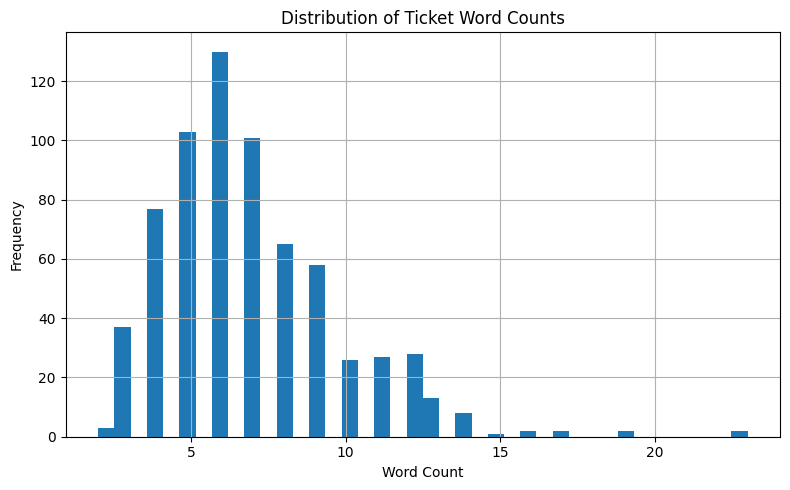

In [7]:
# We're not doing sentiment analysis, but perhaps the title length will give us some insight? 
capstone['text_length'] = capstone['Title'].apply(lambda x: len(x.split()))

capstone['text_length'].hist(bins=40, figsize=(8, 5))
plt.title('Distribution of Ticket Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('images/word_distribution.png')
plt.show()

In [9]:
# Looks like the marjority of tickets are between 5-10 words. 
# Future research: What is hte count of the ticket description if applicable?  It could tell us that perhaps the user tried
# troubleshooting on their own and took the time to write a detailed description and provide more information/details. 

## 1. Baseline model - Naive Bayes


In [10]:
# Libaries for modeling
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, cross_val_predict

In [11]:
# We're going to go with Naive Bayes as our baseline model. Lets start with naive bayes and tdidf vectorizer w no arguments
# specifying a min_df value even with .05 will give us no scores for hardware and network classes. So we will not specify 
# a min_df value. 
y = capstone['Type']
cv = CountVectorizer(stop_words='english', ngram_range=(1,2))
X = cv.fit_transform(capstone['clean_title'])
Xdf = pd.DataFrame(X.toarray(), columns=cv.get_feature_names_out())
Xdf.head()


,10452,10452 investigation,11,11 got,12345,12345 data,2023,2023 workstation,2fa,2fa code,...,zone issue,zoom,zoom account,zoom admin,zoom breakout,zoom meeting,zoom pro,zoom recording,zoom room,zoom webinar
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Future research/improvements: 
Experiment with different n-gram ranges 

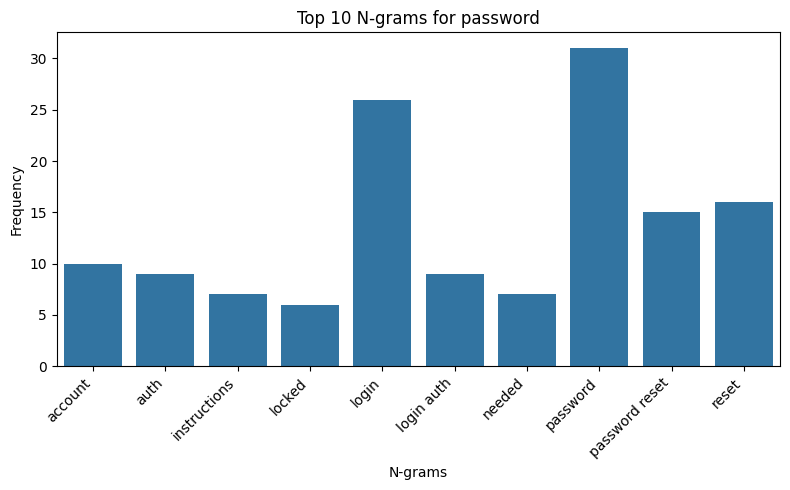

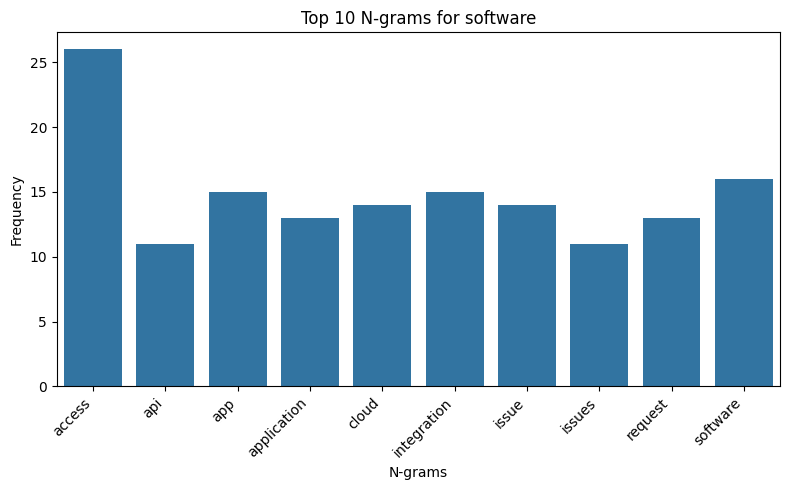

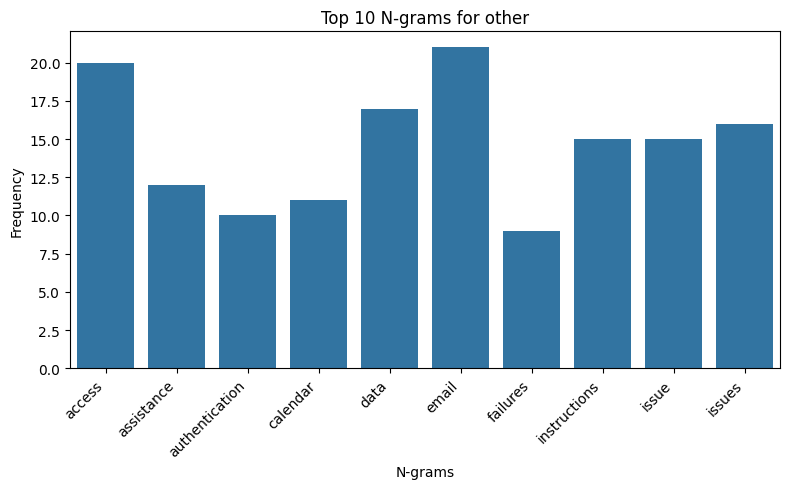

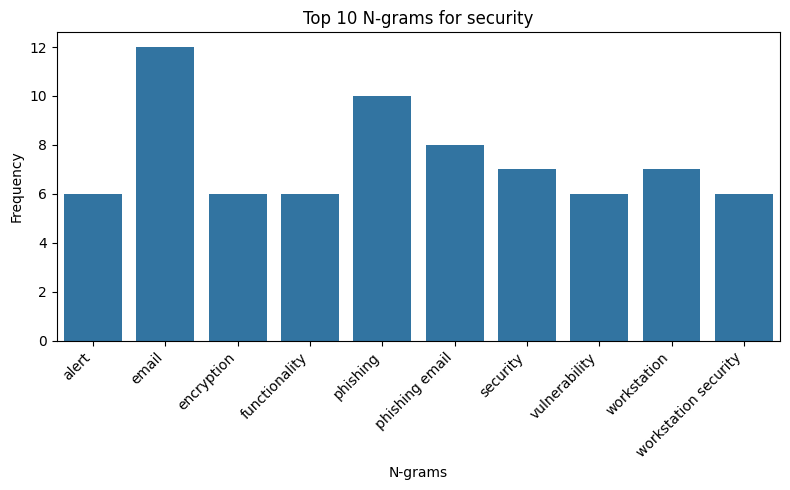

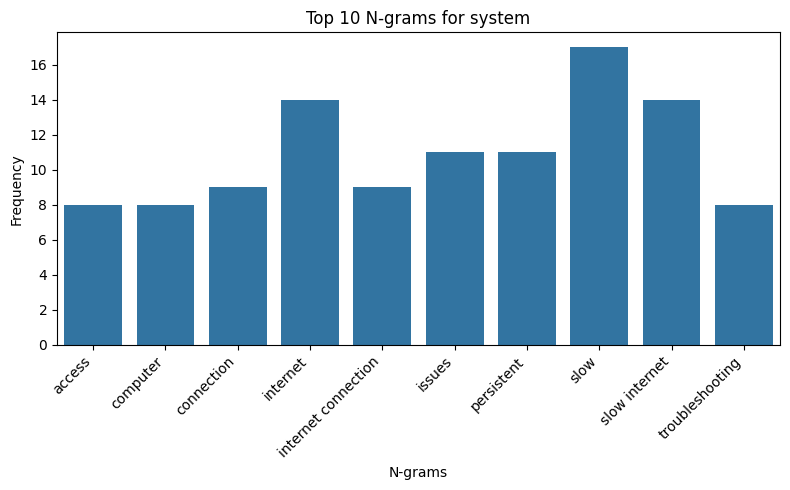

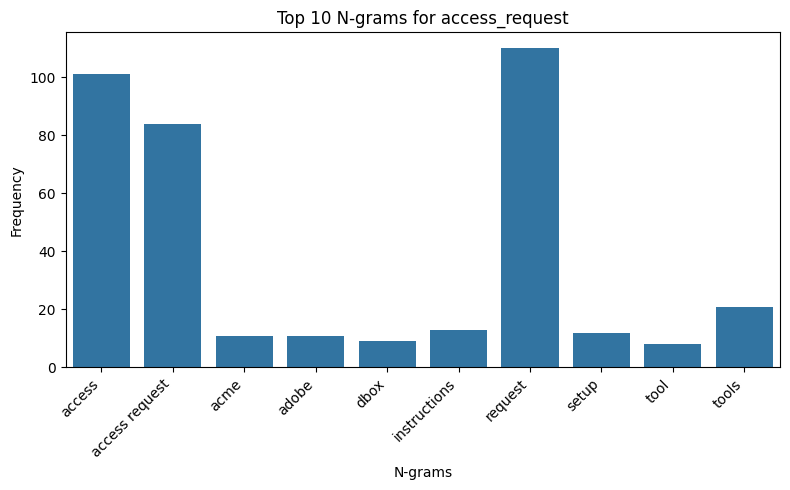

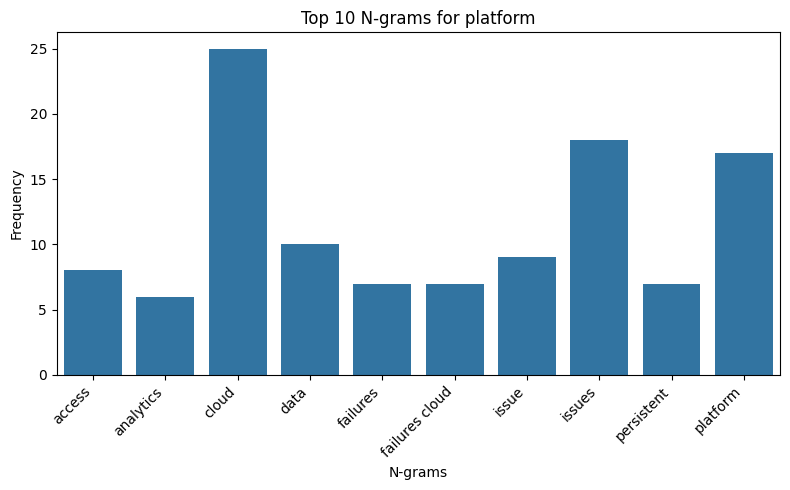

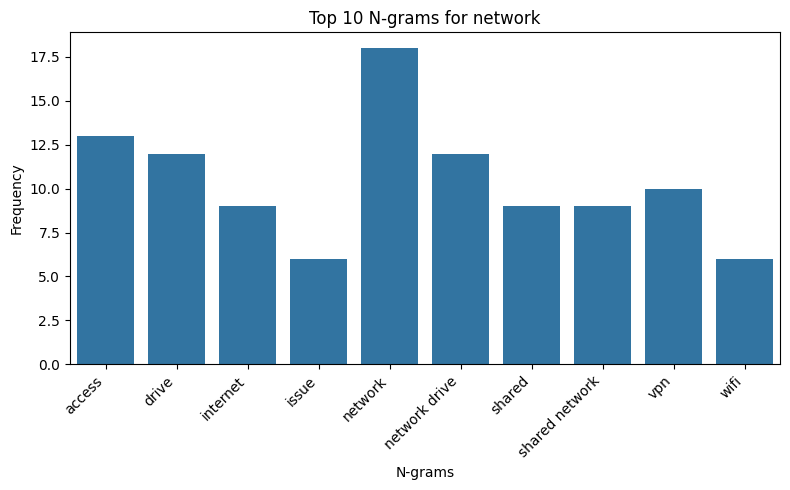

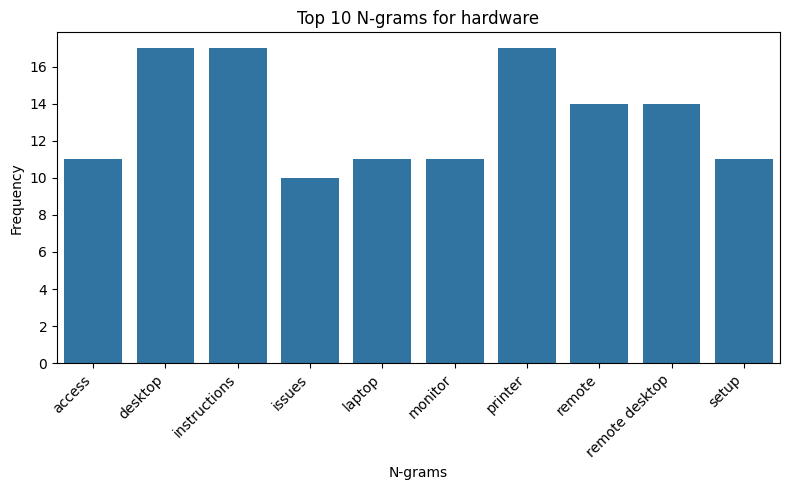

In [23]:
# Let's plot Top N-grams per class to get some insight
for label in capstone['Type'].unique(): 
    subset = capstone[capstone['Type'] == label]['Title'] 
    vec = CountVectorizer(stop_words='english', ngram_range=(1,2), max_features=10)
    vec.fit(subset)
    freqs = vec.transform(subset).sum(axis=0).A1
    terms = vec.get_feature_names_out()
    pd.Series(freqs, index=terms).sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=terms, y=freqs)
    plt.title(f'Top 10 N-grams for {label}')
    plt.xlabel('N-grams')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'images/{label}_ngrams.png')
    plt.show()


In [13]:
X_train, X_test, y_train, y_test = train_test_split(Xdf, y, test_size=0.2, random_state=42)

# Model 
nb = MultinomialNB()
nb.fit(X_train, y_train)

# Predict
y_pred = nb.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7007299270072993
                precision    recall  f1-score   support

access_request       0.67      0.93      0.78        28
      hardware       0.80      0.86      0.83        14
       network       0.80      0.57      0.67         7
         other       0.74      0.50      0.60        28
      password       0.86      0.75      0.80         8
      platform       0.27      0.60      0.38         5
      security       1.00      0.38      0.55         8
      software       0.76      0.73      0.75        26
        system       0.69      0.69      0.69        13

      accuracy                           0.70       137
     macro avg       0.73      0.67      0.67       137
  weighted avg       0.74      0.70      0.70       137



In [14]:
vectorizers = {
    'tfidf': TfidfVectorizer(),
    'CountVectorizer': CountVectorizer(),
    'tfidf (stop+bigrams)': TfidfVectorizer(stop_words="english", ngram_range=(1,2)),
    'CountVectorizer (stop+bigrams)': CountVectorizer(stop_words="english", ngram_range=(1,2))
}

In [15]:
results = {}

X_train, X_test, y_train, y_test = train_test_split(capstone['clean_title'], capstone['Type'], test_size=0.2,
    random_state=42,
    stratify=capstone['Type']
)

# I'm adding the zero_division=0 argument to the classification report to handle cases where a class might not be predicted at all, 
# or because there's not enough supporting data in my unbalanced dataset, but still think what we have is important. 

for name, vectorizer in vectorizers.items():
    pipeline = Pipeline([
        ('vectorizer', vectorizer),
        ('clf', MultinomialNB())
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    report = classification_report(y_test, y_pred, zero_division=0,output_dict=True)
    results[name] = report

print("\nNaive Bayes - F1 Score Summary:")
f1_scores = {name: results[name]['weighted avg']['f1-score'] for name in results}
sorted_names = sorted(f1_scores, key=f1_scores.get, reverse=True)
for name in sorted_names:
    print(f"  {f1_scores[name]:.4f}  →  {name}")


Naive Bayes - F1 Score Summary:
  0.6654  →  CountVectorizer (stop+bigrams)
  0.6625  →  CountVectorizer
  0.6061  →  tfidf
  0.5950  →  tfidf (stop+bigrams)


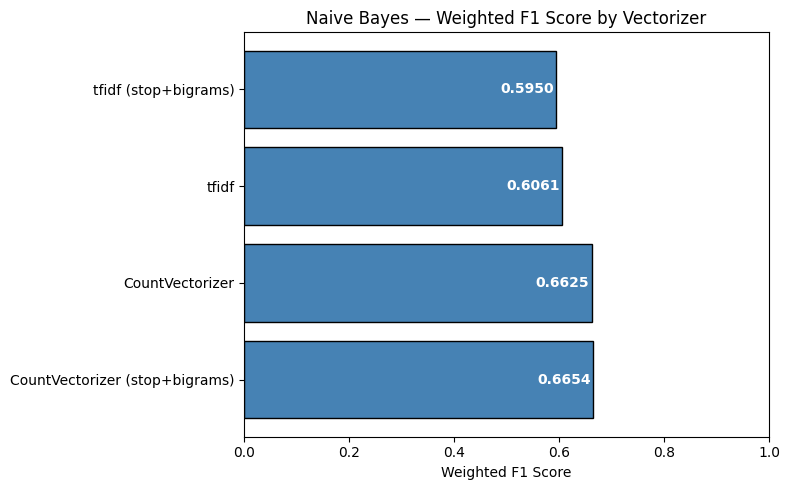

In [ ]:
sorted_scores = [(name, f1_scores[name]) for name in sorted_names]
labels = [name for name, _ in sorted_scores]
scores = [score for _, score in sorted_scores]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(labels, scores, color='steelblue', edgecolor='black')

# Add score labels on each bar
for bar, score in zip(bars, scores):
    ax.text(bar.get_width() - 0.005, bar.get_y() + bar.get_height() / 2,
            f'{score:.4f}', va='center', ha='right', color='white', fontweight='bold')

ax.set_xlabel('Weighted F1 Score')
ax.set_title('Naive Bayes — Weighted F1 Score by Vectorizer')
ax.set_xlim(0, 1.0)
plt.tight_layout()
plt.savefig('images/naive_bayes_comparison.png')
plt.show()

We have some pretty good results here for our Baseline model.  Even with our network classification label, with low support the recall outstanding.  So now let's see how Naive Bayes tacks up against other classification models. 

# 2. Comparison Models

In [17]:
models = {
    'LogisticRegression': LogisticRegression(class_weight='balanced',  max_iter=1000),
    'linearSVC': LinearSVC(class_weight='balanced', max_iter=5000),
    'RandomForest': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42,n_jobs=-1)
}

In [18]:
import time
comparison_results = {}

for vec_name, vectorizer in vectorizers.items():
    for model_name, model in models.items():
        
        combo_name = f"{vec_name} + {model_name}"
        print(f"Training: {combo_name}...")
        pipeline = Pipeline([
            ('vectorizer', vectorizer),
            ('clf', model)
        ])

        start = time.time()
        pipeline.fit(X_train, y_train)
        duration = time.time() - start
        print(f"  Done in {duration:.2f} seconds.")

        y_pred = pipeline.predict(X_test)
        report_str = classification_report(y_test, y_pred, zero_division=0)
        report = classification_report(y_test, y_pred, zero_division=0,output_dict=True)
        #print(combo_name)
        #print(report_str)
        comparison_results[combo_name] = report

print("\n F1 Score Summary (weighted avg):")
f1_scores = {name: comparison_results[name]['weighted avg']['f1-score'] for name in comparison_results}
sorted_names = sorted(f1_scores, key=f1_scores.get, reverse=True)
for name in sorted_names:
    print(f"  {f1_scores[name]:.4f}  →  {name}")

Training: tfidf + LogisticRegression...
  Done in 0.02 seconds.
Training: tfidf + linearSVC...
  Done in 0.01 seconds.
Training: tfidf + RandomForest...
  Done in 0.12 seconds.
Training: CountVectorizer + LogisticRegression...
  Done in 0.02 seconds.
Training: CountVectorizer + linearSVC...
  Done in 0.01 seconds.
Training: CountVectorizer + RandomForest...
  Done in 0.10 seconds.
Training: tfidf (stop+bigrams) + LogisticRegression...
  Done in 0.03 seconds.
Training: tfidf (stop+bigrams) + linearSVC...
  Done in 0.01 seconds.
Training: tfidf (stop+bigrams) + RandomForest...
  Done in 0.09 seconds.
Training: CountVectorizer (stop+bigrams) + LogisticRegression...
  Done in 0.03 seconds.
Training: CountVectorizer (stop+bigrams) + linearSVC...
  Done in 0.01 seconds.
Training: CountVectorizer (stop+bigrams) + RandomForest...
  Done in 0.10 seconds.

 F1 Score Summary (weighted avg):
  0.8310  →  CountVectorizer + linearSVC
  0.7920  →  CountVectorizer (stop+bigrams) + linearSVC
  0.7897  

### Model comparison
Our top models. 

0.7282  →  tfidf + RandomForest
0.7247  →  tfidf (stop+bigrams) + RandomForest
0.7156  →  CountVectorizer (stop+bigrams) + RandomForest

# 3. Grid search for best hyperparameters 


In [19]:
pipelines = {
    'MultinomialNB': Pipeline([
        ('vec',TfidfVectorizer()),
        ('clf', MultinomialNB())
    ]),
    'lr': Pipeline([
        ('vec', TfidfVectorizer()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=5000))
    ]),
    'LinearSVC': Pipeline([
        ('vec', TfidfVectorizer()),
        ('clf', LinearSVC(class_weight='balanced', max_iter=5000))
    ]),
    'RandomForest': Pipeline([
        ('vec', TfidfVectorizer()),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
    ])
}

params = {
    'MultinomialNB': {
        'vec':              [TfidfVectorizer(),CountVectorizer()],
        'vec__stop_words':  [None, 'english'],
        'vec__ngram_range': [(1,1), (1,2)],
        'clf__alpha':       [0.01, 0.1, 0.5, 1.0]
    },
    'lr': {
        'vec':              [TfidfVectorizer(),CountVectorizer()],
        'vec__stop_words':  [None, 'english'],
        'vec__ngram_range': [(1,1), (1,2)],
        'clf__C':           [0.1, 1.0, 10.0],
        'clf__max_iter':    [1000,5000,10000]
    },
    'LinearSVC': {
        'vec':              [TfidfVectorizer(),CountVectorizer()],
        'vec__stop_words':  [None, 'english'],
        'vec__ngram_range': [(1,1), (1,2)],
        'clf__C':           [0.1, 1.0, 10.0],
        'clf__max_iter':    [1000,5000,10000]
    },
    'RandomForest': {
        'vec':              [TfidfVectorizer(),CountVectorizer()],
        'vec__stop_words':  [None, 'english'],
        'vec__ngram_range': [(1,1), (1,2)],        
        'clf__n_estimators': [100],
        'clf__max_depth':    [None, 20],
    }
}

In [20]:
grid_results = {}
elapsed_times = {}

# I tried toying with different max_iter values for linear models, but it the warnings persist. So ignoring for now.
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

for name in pipelines:
    start = time.time()

    gs = GridSearchCV(
        pipelines[name], params[name], cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0
    )
    gs.fit(X_train, y_train)
    elapsed = time.time() - start
    elapsed_times[name] = elapsed


    grid_results[name] = gs
    print(name)
    print(f" {elapsed:.2f}s")
    print(f" Best params : {gs.best_params_}")
    print(f" Best CV F1  : {gs.best_score_:.4f}\n")

f1_scores = {}
for name, gs in grid_results.items():
    y_pred = gs.predict(X_test)
    report = classification_report(y_test, y_pred,
                                   output_dict=True, zero_division=0)
    f1_scores[name] = report['weighted avg']['f1-score']

sorted_names = sorted(f1_scores, key=f1_scores.get, reverse=True)
for name in sorted_names:
    print(f"  {f1_scores[name]:.4f}  →  {name}  |  best params: {grid_results[name].best_params_}")

MultinomialNB
 1.43s
 Best params : {'clf__alpha': 1.0, 'vec': CountVectorizer(), 'vec__ngram_range': (1, 1), 'vec__stop_words': 'english'}
 Best CV F1  : 0.6976

lr
 0.63s
 Best params : {'clf__C': 10.0, 'clf__max_iter': 1000, 'vec': CountVectorizer(), 'vec__ngram_range': (1, 1), 'vec__stop_words': None}
 Best CV F1  : 0.8450

LinearSVC
 0.44s
 Best params : {'clf__C': 10.0, 'clf__max_iter': 1000, 'vec': CountVectorizer(), 'vec__ngram_range': (1, 1), 'vec__stop_words': None}
 Best CV F1  : 0.8556

RandomForest
 1.12s
 Best params : {'clf__max_depth': None, 'clf__n_estimators': 100, 'vec': TfidfVectorizer(), 'vec__ngram_range': (1, 1), 'vec__stop_words': None}
 Best CV F1  : 0.7984

  0.8390  →  LinearSVC  |  best params: {'clf__C': 10.0, 'clf__max_iter': 1000, 'vec': CountVectorizer(), 'vec__ngram_range': (1, 1), 'vec__stop_words': None}
  0.8345  →  lr  |  best params: {'clf__C': 10.0, 'clf__max_iter': 1000, 'vec': CountVectorizer(), 'vec__ngram_range': (1, 1), 'vec__stop_words': Non

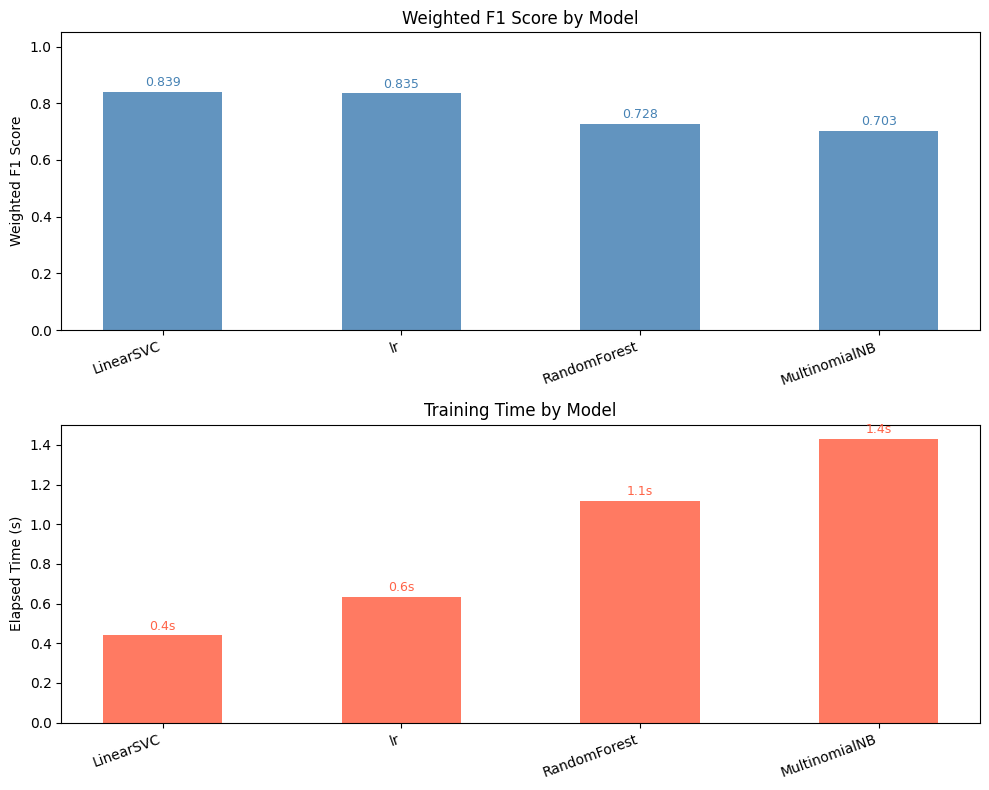

In [22]:
# Plot scores and time
sorted_names = sorted(f1_scores, key=f1_scores.get, reverse=True)
f1_vals = [f1_scores[n] for n in sorted_names]
time_vals = [elapsed_times[n] for n in sorted_names]

x = np.arange(len(sorted_names))
width = 0.5

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# -- F1 Score plot --
bars = ax1.bar(x, f1_vals, width, color='steelblue', alpha=0.85)
ax1.set_ylabel('Weighted F1 Score')
ax1.set_ylim(0, 1.05)
ax1.set_xticks(x)
ax1.set_xticklabels(sorted_names, rotation=20, ha='right')
ax1.set_title('Weighted F1 Score by Model')

for bar, val in zip(bars, f1_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, color='steelblue')

# -- Training Time plot --
bars2 = ax2.bar(x, time_vals, width, color='tomato', alpha=0.85)
ax2.set_ylabel('Elapsed Time (s)')
ax2.set_xticks(x)
ax2.set_xticklabels(sorted_names, rotation=20, ha='right')
ax2.set_title('Training Time by Model')

for bar, val in zip(bars2, time_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(time_vals) * 0.01,
             f'{val:.1f}s', ha='center', va='bottom', fontsize=9, color='tomato')

plt.tight_layout()
plt.savefig('images/top_model_comparison.png')
plt.show()

# Winner: CountVectorizer + LinearSVC
Using the following parameters: 

0.8390  →  LinearSVC  |  
```
best params: {   
  'clf__C': 10.0, 
  'clf__max_iter': 1000,  
  'vec': CountVectorizer(), 
  'vec__ngram_range': (1, 1), 
  'vec__stop_words': None
}
```


# Cross Validation
Let's do cross validation on our top model.


In [24]:
svc_pipe = Pipeline([
    ('vec', CountVectorizer(stop_words=None, ngram_range=(1, 1))),
    ('clf', LinearSVC(C=10.0, class_weight='balanced', max_iter=1000, random_state=42))
])

In [26]:
svc_pipe.fit(X_train, y_train)

train_score = svc_pipe.score(X_train, y_train)
test_score = svc_pipe.score(X_test, y_test)

scores = cross_val_score(svc_pipe, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)
print(f"Train F1 Score: {svc_pipe.score(X_train, y_train):.4f}")
print(f"Test F1 Score: {svc_pipe.score(X_test, y_test):.4f}")
print(f"Gap : {svc_pipe.score(X_train, y_train) - svc_pipe.score(X_test, y_test):.4f}")

print(f"Cross-validated F1 scores: {scores.round(4)}")
print(f"Mean F1 score: {scores.mean():.4f}")
print(f"Standard Deviation of F1 scores: {scores.std():.4f}") 


Train F1 Score: 1.0000
Test F1 Score: 0.8394
Gap : 0.1606
Cross-validated F1 scores: [0.8544 0.8922 0.8612 0.8546 0.8156]
Mean F1 score: 0.8556
Standard Deviation of F1 scores: 0.0244


## Cross Validation and Confusion Matrix check 


                precision    recall  f1-score   support

access_request       0.92      0.92      0.92       105
      hardware       0.92      0.81      0.86        69
       network       0.78      0.93      0.85        30
         other       0.78      0.89      0.83       102
      password       1.00      1.00      1.00        41
      platform       0.81      0.74      0.77        39
      security       0.85      0.77      0.81        30
      software       0.88      0.81      0.84        83
        system       0.76      0.78      0.77        49

      accuracy                           0.86       548
     macro avg       0.86      0.85      0.85       548
  weighted avg       0.86      0.86      0.86       548



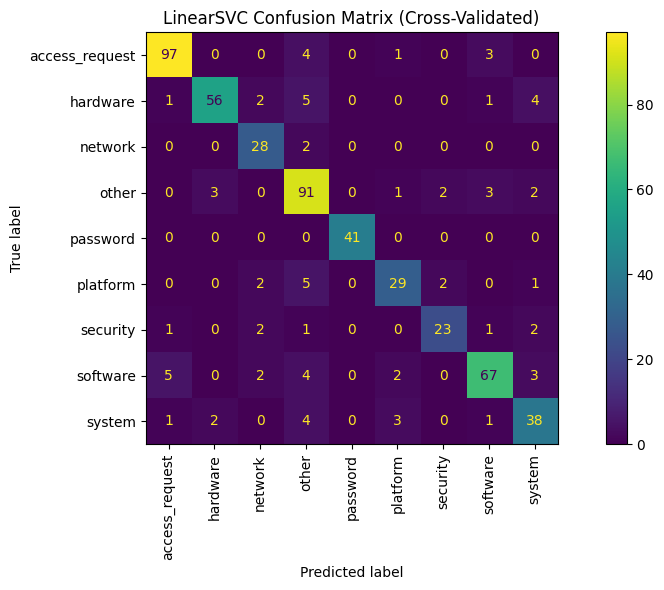

In [28]:
y_pred = cross_val_predict(svc_pipe, X_train, y_train, cv=5)
print(classification_report(y_train, y_pred))

fig, ax = plt.subplots(figsize=(10, 6))  

ConfusionMatrixDisplay.from_predictions(
    y_train, y_pred,
    ax=ax,
    xticks_rotation='vertical'  # helps if you have many category labels
)

plt.title('LinearSVC Confusion Matrix (Cross-Validated)')
plt.tight_layout()
plt.savefig('images/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Persist our model for deployment

In [ ]:
# Uncomment and run once if you currently do not have these installed.
#!pip install fastapi joblib pydantic uvicorn --user

In [31]:
import joblib
joblib.dump(svc_pipe, 'deployment/final_model.pkl')

['deployment/final_model.pkl']

# Future Improvements: 
Add additional data for some of the weaker classes  - security, platform, system.  

Other is a catch all and there may be some classes entering the class.  However, one can argue that some of these classes like hardware, system, software, and platform are specific to its environment.  So the model would have to be tailored as such. 

Titles such as "I have a general question about my account." - are classified as access_request, which is not entirely wrong but should probably be other - or in a separate category for general inquiries. Experimenting with n-grams and/or rearranging our keyword map order may be able to help. 

We also take a look at the tickets that were classifed as 'other' and thoe appear to be classified correctly. A feature request would be to look at reclassifying some of these tickets.  As mentioned previously, some of our classes should probably be tailored depending on the environment. 

